In [16]:
import sys

print(sys.executable)

c:\Users\KESHAV\ML Project\Linear_Regression Project\.venv\Scripts\python.exe


In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

In [18]:
df = pd.read_csv("../../data/raw/AmesHousing.csv")

print("Shape:", df.shape)


df.head()

Shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [20]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,2929.000000,2929.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2928.000000,2928.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2771.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,442.629566,49.722431,559.262547,1051.614544,1159.557679,335.455973,4.676792,1499.690444,0.431352,0.061134,1.566553,0.379522,2.854266,1.044369,6.443003,0.599317,1978.132443,1.766815,472.819734,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,455.590839,169.168476,439.494153,440.615067,391.890885,428.395715,46.310510,505.508887,0.524820,0.245254,0.552941,0.502629,0.827731,0.214076,1.572964,0.647921,25.528411,0.760566,215.046549,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,0.000000,219.000000,793.000000,876.250000,0.000000,0.000000,1126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1960.000000,1.000000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,0.000000,466.000000,990.000000,1084.000000,0.000000,0.000000,1442.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,734.000000,0.000000,802.000000,1302.000000,1384.000000,703.750000,0.000000,1742.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [21]:
df.isnull().sum()

Order                 0
PID                   0
MS SubClass           0
MS Zoning             0
Lot Frontage        490
Lot Area              0
Street                0
Alley              2732
Lot Shape             0
Land Contour          0
Utilities             0
Lot Config            0
Land Slope            0
Neighborhood          0
Condition 1           0
Condition 2           0
Bldg Type             0
House Style           0
Overall Qual          0
Overall Cond          0
Year Built            0
Year Remod/Add        0
Roof Style            0
Roof Matl             0
Exterior 1st          0
Exterior 2nd          0
Mas Vnr Type       1775
Mas Vnr Area         23
Exter Qual            0
Exter Cond            0
Foundation            0
Bsmt Qual            80
Bsmt Cond            80
Bsmt Exposure        83
BsmtFin Type 1       80
BsmtFin SF 1          1
BsmtFin Type 2       81
BsmtFin SF 2          1
Bsmt Unf SF           1
Total Bsmt SF         1
Heating               0
Heating QC      

In [22]:
column_info = {
    "Order": "Row/order number of the house record",
    "PID": "Unique property identification number",
    "MS SubClass": "Type/class of dwelling based on construction classification",
    "MS Zoning": "General zoning classification of the property",

    "Lot Frontage": "Length of the property's lot frontage facing the street",
    "Lot Area": "Total area of the property lot",

    "Street": "Type of road access to the property",
    "Alley": "Type of alley access, if available",

    "Lot Shape": "Shape of the property lot",
    "Land Contour": "General flatness/topography of the property",
    "Utilities": "Type/availability of utilities",
    "Lot Config": "Configuration/location of the lot",
    "Land Slope": "Slope of the property",

    "Neighborhood": "Physical location/neighborhood of the house",
    "Condition 1": "Proximity to important nearby conditions/features",
    "Condition 2": "Secondary proximity condition",

    "Bldg Type": "Type of residential building",
    "House Style": "Style/type of house",

    "Overall Qual": "Overall material and finish quality of the house",
    "Overall Cond": "Overall condition of the house",

    "Year Built": "Original construction year",
    "Year Remod/Add": "Year of remodeling or addition",

    "Roof Style": "Type/style of roof",
    "Roof Matl": "Roof material",

    "Exterior 1st": "Primary exterior covering",
    "Exterior 2nd": "Secondary exterior covering",

    "Mas Vnr Type": "Masonry veneer type",
    "Mas Vnr Area": "Area of masonry veneer",

    "Exter Qual": "Exterior material quality",
    "Exter Cond": "Exterior material condition",

    "Foundation": "Type of foundation",

    "Bsmt Qual": "Basement quality",
    "Bsmt Cond": "Basement condition",
    "Bsmt Exposure": "Basement exposure/walkout access",

    "BsmtFin Type 1": "Quality/type of finished basement area",
    "BsmtFin SF 1": "Finished basement area, type 1",

    "BsmtFin Type 2": "Quality/type of second finished basement area",
    "BsmtFin SF 2": "Finished basement area, type 2",

    "Bsmt Unf SF": "Unfinished basement area",
    "Total Bsmt SF": "Total basement area",

    "Heating": "Heating system type",
    "Heating QC": "Heating quality and condition",

    "Central Air": "Whether central air conditioning is present",
    "Electrical": "Electrical system type",

    "1st Flr SF": "First-floor living area",
    "2nd Flr SF": "Second-floor living area",
    "Low Qual Fin SF": "Low-quality finished living area",

    "Gr Liv Area": "Above-ground living area",

    "Bsmt Full Bath": "Number of full bathrooms in basement",
    "Bsmt Half Bath": "Number of half bathrooms in basement",

    "Full Bath": "Number of full bathrooms above ground",
    "Half Bath": "Number of half bathrooms above ground",

    "Bedroom AbvGr": "Number of bedrooms above ground",
    "Kitchen AbvGr": "Number of kitchens above ground",
    "Kitchen Qual": "Kitchen quality",

    "TotRms AbvGrd": "Total rooms above ground",
    "Functional": "Overall functionality of the house",

    "Fireplaces": "Number of fireplaces",
    "Fireplace Qu": "Fireplace quality",

    "Garage Type": "Garage location/type",
    "Garage Yr Blt": "Year garage was built",
    "Garage Finish": "Interior finish of garage",

    "Garage Cars": "Garage capacity in cars",
    "Garage Area": "Garage area",

    "Garage Qual": "Garage quality",
    "Garage Cond": "Garage condition",

    "Paved Drive": "Type/quality of driveway paving",

    "Wood Deck SF": "Wood deck area",
    "Open Porch SF": "Open porch area",
    "Enclosed Porch": "Enclosed porch area",
    "3Ssn Porch": "Three-season porch area",
    "Screen Porch": "Screened porch area",

    "Pool Area": "Swimming pool area",
    "Pool QC": "Pool quality",

    "Fence": "Fence quality/type",
    "Misc Feature": "Miscellaneous additional feature",
    "Misc Val": "Value of miscellaneous feature",

    "Mo Sold": "Month in which the house was sold",
    "Yr Sold": "Year in which the house was sold",

    "Sale Type": "Type of sale transaction",
    "Sale Condition": "Condition/circumstance of the sale",

    "SalePrice": "Final sale price of the house — TARGET"
}

for column, description in column_info.items():
    print(f"{column:20} -> {description}")

Order                -> Row/order number of the house record
PID                  -> Unique property identification number
MS SubClass          -> Type/class of dwelling based on construction classification
MS Zoning            -> General zoning classification of the property
Lot Frontage         -> Length of the property's lot frontage facing the street
Lot Area             -> Total area of the property lot
Street               -> Type of road access to the property
Alley                -> Type of alley access, if available
Lot Shape            -> Shape of the property lot
Land Contour         -> General flatness/topography of the property
Utilities            -> Type/availability of utilities
Lot Config           -> Configuration/location of the lot
Land Slope           -> Slope of the property
Neighborhood         -> Physical location/neighborhood of the house
Condition 1          -> Proximity to important nearby conditions/features
Condition 2          -> Secondary proximity condit

## What each feature actually looks like 

In [24]:
for column in df.columns:
    print("\n" + "=" * 60)
    print(f"COLUMN: {column}")
    print("=" * 60)

    print("Data type:", df[column].dtype)
    print("Missing:", df[column].isna().sum())
    print("Unique values:", df[column].nunique())

    print("\nSample values:")
    print(df[column].dropna().head(10).tolist())


COLUMN: Order
Data type: int64
Missing: 0
Unique values: 2930

Sample values:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

COLUMN: PID
Data type: int64
Missing: 0
Unique values: 2930

Sample values:
[526301100, 526350040, 526351010, 526353030, 527105010, 527105030, 527127150, 527145080, 527146030, 527162130]

COLUMN: MS SubClass
Data type: int64
Missing: 0
Unique values: 16

Sample values:
[20, 20, 20, 20, 60, 60, 120, 120, 120, 60]

COLUMN: MS Zoning
Data type: str
Missing: 0
Unique values: 7

Sample values:
['RL', 'RH', 'RL', 'RL', 'RL', 'RL', 'RL', 'RL', 'RL', 'RL']

COLUMN: Lot Frontage
Data type: float64
Missing: 490
Unique values: 128

Sample values:
[141.0, 80.0, 81.0, 93.0, 74.0, 78.0, 41.0, 43.0, 39.0, 60.0]

COLUMN: Lot Area
Data type: int64
Missing: 0
Unique values: 1960

Sample values:
[31770, 11622, 14267, 11160, 13830, 9978, 4920, 5005, 5389, 7500]

COLUMN: Street
Data type: str
Missing: 0
Unique values: 2

Sample values:
['Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pav

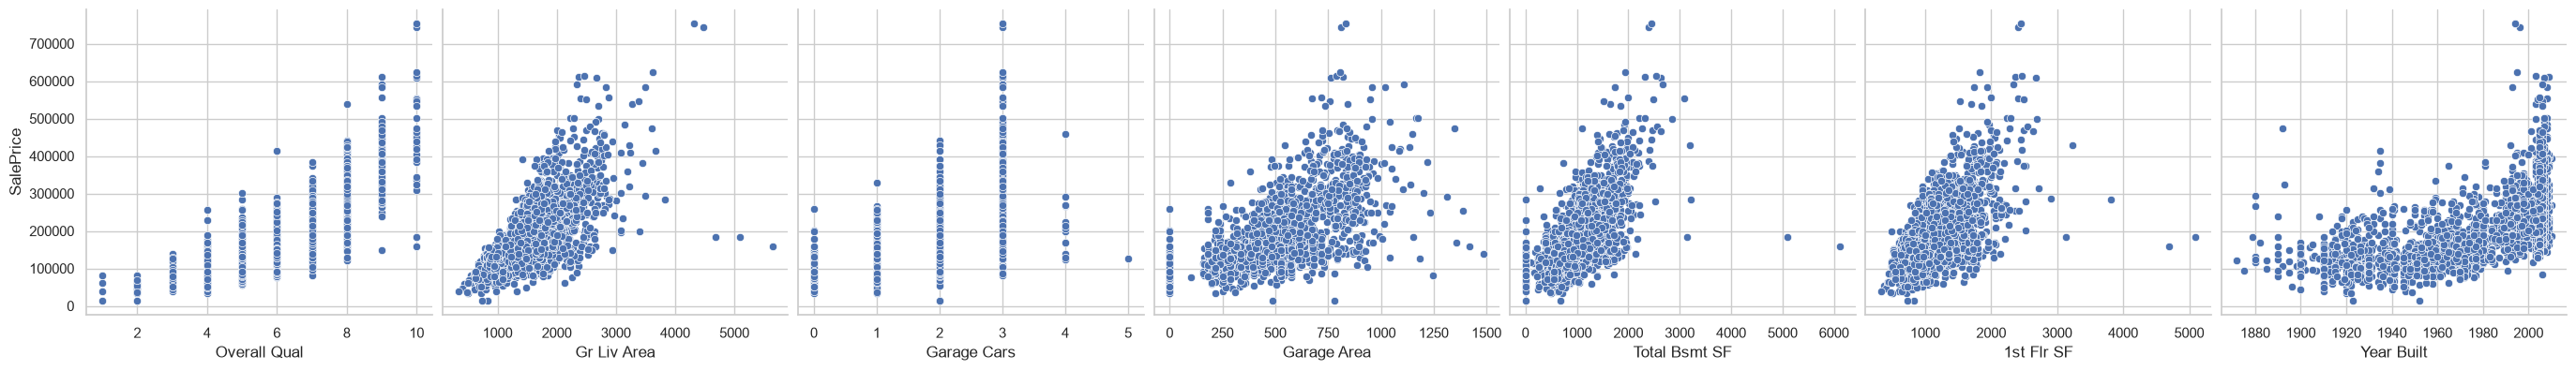

In [25]:
features = [
    "SalePrice",
    "Overall Qual",
    "Gr Liv Area",
    "Garage Cars",
    "Garage Area",
    "Total Bsmt SF",
    "1st Flr SF",
    "Year Built"
]

sns.pairplot(
    df[features],
    y_vars=["SalePrice"],
    x_vars=features[1:],
    height=4
)

plt.show()

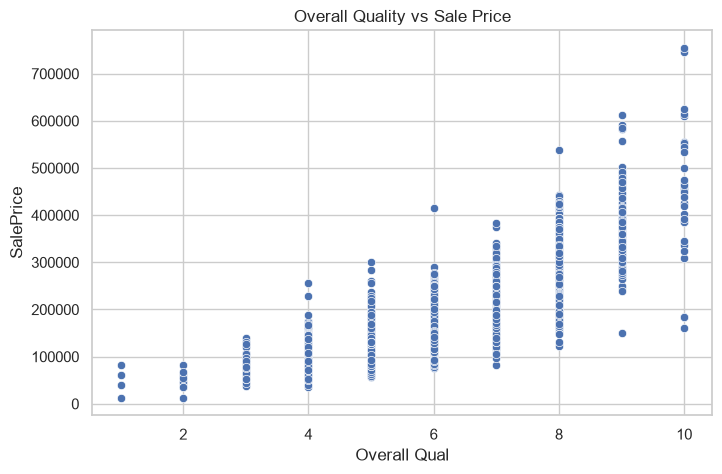

In [26]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Overall Qual",
    y="SalePrice"
)

plt.title("Overall Quality vs Sale Price")
plt.show()

In [27]:
df = df.drop(columns=["Order", "PID"])
df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [ ]:
df_fe = df.copy()

# -----------------------------
# Remove identifiers
# -----------------------------

df_fe = df_fe.drop(columns=["Order", "PID"])


# -----------------------------
# Total square footage
# -----------------------------

df_fe["TotalSF"] = (
    df_fe["Total Bsmt SF"]
    + df_fe["1st Flr SF"]
    + df_fe["2nd Flr SF"]
)


# -----------------------------
# Total bathrooms
# -----------------------------

df_fe["TotalBathrooms"] = (
    df_fe["Full Bath"]
    + 0.5 * df_fe["Half Bath"]
    + df_fe["Bsmt Full Bath"]
    + 0.5 * df_fe["Bsmt Half Bath"]
)


# -----------------------------
# Total porch/deck area
# -----------------------------

df_fe["TotalPorchSF"] = (
    df_fe["Wood Deck SF"]
    + df_fe["Open Porch SF"]
    + df_fe["Enclosed Porch"]
    + df_fe["3Ssn Porch"]
    + df_fe["Screen Porch"]
)


# -----------------------------
# Total finished basement area
# -----------------------------

df_fe["TotalBsmtFinSF"] = (
    df_fe["BsmtFin SF 1"]
    + df_fe["BsmtFin SF 2"]
)


# -----------------------------
# House age
# -----------------------------

df_fe["HouseAge"] = (
    df_fe["Yr Sold"]
    - df_fe["Year Built"]
)


# -----------------------------
# Years since remodel
# -----------------------------

df_fe["YearsSinceRemodel"] = (
    df_fe["Yr Sold"]
    - df_fe["Year Remod/Add"]
)


# -----------------------------
# Garage age
# -----------------------------

df_fe["GarageAge"] = (
    df_fe["Yr Sold"]
    - df_fe["Garage Yr Blt"]
)

KeyError: "['Order', 'PID'] not found in axis"